In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import json

import torch

In [2]:
def calculate_rolling_average(
        data: np.ndarray,
        window_size: int = 10
) -> np.ndarray:
    return np.convolve(np.pad(data, pad_width=int(window_size/2), mode="reflect"), np.ones(window_size)/window_size, mode='valid')[:-1]

In [3]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [4]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [5]:
def drop_first_inertial_period(
        data,
        variable,
        case_index,
        latitude,
        dt = 1800,
        shift_by = None
):
    inertial_period = calculate_T(latitude=latitude)
    first_index = int(inertial_period / dt)
    return data[variable][case_index,first_index:].values if not shift_by else data[variable][case_index,first_index-shift_by:-shift_by].values

In [6]:
def get_data(
        data,
        variable,
        latitudes,
        n_cases,
        dt = 1800,
        shift_by = None
):
    lst = []

    for i in range(n_cases):
        lst.append(drop_first_inertial_period(data, variable, i, latitudes[i], dt, shift_by).tolist())

    return np.asarray(sum(lst, []))

In [7]:
data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_validation_2283_corrected'

bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_bl.nc'))
M_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_M.nc'))
u_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_u_surf.nc'))
v_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_v_surf.nc'))
u_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_u_bl.nc'))
v_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_v_bl.nc'))
SS_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_SS_bl_avg.nc'))
NN_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_NN_bl_avg.nc'))
wb_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_wb_dataset.nc'))

with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

In [8]:
M_data_mean = np.load(os.path.join(data_directory,"ePBL_paper_validation_2283_corrected_mean_Ms.npy"))

In [9]:
bl_data_mean = np.load(os.path.join(data_directory,"ePBL_paper_validation_2283_corrected_mean_bls.npy"))

In [10]:
SS_bl_data

<xarray.Dataset> Size: 759kB
Dimensions:     (case: 216, time: 433)
Coordinates:
  * case        (case) <U8 7kB 'case_1' 'case_2' ... 'case_215' 'case_216'
  * time        (time) datetime64[ns] 3kB 2011-04-01 ... 2011-04-10
Data variables:
    SS_bl_mean  (case, time) float64 748kB ...

In [11]:
bl = drop_first_inertial_period(bl_data, "bl", 0, 90)

In [12]:
rho0 = 1027
g = 9.81
alpha = 2e-4
cp = 4e3

n_cases, _ = bl_data.bl.values.shape
latitudes = [case["lat"] for case in gotm_case_dict.values()]

Ms = get_data(M_data, "M", latitudes, n_cases)
bls = get_data(bl_data, "bl", latitudes, n_cases)
bls_im1 = get_data(bl_data, "bl", latitudes, n_cases, shift_by=1)
us = get_data(u_data, "u_surf", latitudes, n_cases)
vs = get_data(v_data, "v_surf", latitudes, n_cases)
us_bl = get_data(u_bl_data, "u_bl", latitudes, n_cases)
vs_bl = get_data(v_bl_data, "v_bl", latitudes, n_cases)
SS_bl = get_data(SS_bl_data, "SS_bl_mean", latitudes, n_cases)
NN_bl = get_data(NN_bl_data, "NN_bl_mean", latitudes, n_cases)
wbs = get_data(wb_data, "wb", latitudes, n_cases)

fs = []
u_stars = []
taus = []
Bs = []
n_timesteps = []

for i in range(n_cases):
    case = gotm_case_dict[f"case_{i+1}"]
    heat_flux = case['heat_flux']
    f = calculate_f(case["lat"])
    u_star = (case['tx'] / rho0) ** 0.5
    tau = case["tx"]
    B = g * alpha * heat_flux / (rho0 * cp)

    bl = drop_first_inertial_period(bl_data, "bl", i, case["lat"])

    n = bl.shape[0]
    n_timesteps.append(n)
    fs.append(np.repeat(f, n).tolist())
    u_stars.append(np.repeat(u_star, n).tolist())
    taus.append(np.repeat(tau, n).tolist())
    Bs.append(np.repeat(B, n).tolist())

fs = np.asarray(sum(fs, []))
u_stars = np.asarray(sum(u_stars, []))
taus = np.asarray(sum(taus, []))
Bs = np.asarray(sum(Bs, []))

surface_magnitudes = taus*np.sqrt(us**2+vs**2)
surface_angles = np.arccos(us*taus/(np.sqrt(us**2+vs**2)*taus))
surface_ekin_input = abs(surface_magnitudes*np.cos(surface_angles))

In [13]:
time = M_data.time.values
start = len(time) - n_timesteps[0]
time_reduced = time[start:]
M_reduced = Ms[:n_timesteps[0]]
bl_reduced = bls[:n_timesteps[0]]
M = M_data.isel(case=0).M.values
bl = bl_data.isel(case=0).bl.values
M_mean = M_data_mean[0]
bl_mean = bl_data_mean[0]

In [14]:
24*2

48

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2278092/2064263278.py:4: SyntaxWarning: invalid escape sequence '\o'
  ax[1].plot(time[-48:], np.repeat(M_mean, len(time[-48:])), color="red", linestyle="dashed", label="equilibrium $\overline{M}$")
/tmp/ipykernel_2278092/2064263278.py:11: SyntaxWarning: invalid escape sequence '\o'
  ax[0].plot(time[-48:], np.repeat(bl_mean, len(time[-48:])), color="red", linestyle="dashed", label="equilibrium $\overline{H}$")


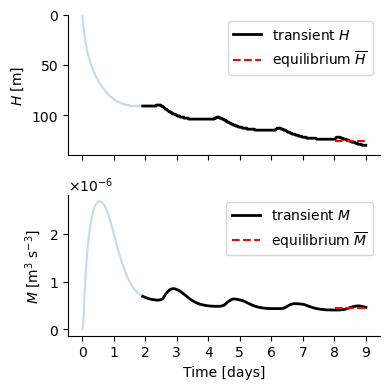

In [17]:
fig, ax = plt.subplots(2,1,figsize=(4,4), tight_layout=True, sharex=True)
ax[1].plot(time, M, color="#c2dbf3")
ax[1].plot(time_reduced, M_reduced, color="black", linewidth=2, label="transient $M$")
ax[1].plot(time[-48:], np.repeat(M_mean, len(time[-48:])), color="red", linestyle="dashed", label="equilibrium $\overline{M}$")
ax[1].set_ylabel("$M$ [m$^3$ s$^{-3}$]")
ax[1].ticklabel_format(style='sci', useMathText=True, scilimits=(-2, 2), axis='y')
ax[1].legend()

ax[0].plot(time, bl, color="#c2dbf3")
ax[0].plot(time_reduced, bl_reduced, color="black", linewidth=2, label="transient $H$")
ax[0].plot(time[-48:], np.repeat(bl_mean, len(time[-48:])), color="red", linestyle="dashed", label="equilibrium $\overline{H}$")
ax[0].set_ylabel("$H$ [m]")
ax[0].legend()
ax[0].set_ylim(140,0)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

xticks = ax[1].get_xticks()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels([i for i, val in enumerate(xticks)])
ax[1].set_xlabel("Time [days]")

plt.savefig("M_and_H_time_series.png", dpi=1500, transparent=True)

In [12]:
from epbl_basic import calculate_M

In [17]:
M, mechanical, convective, Psi = calculate_M(
    H = bls,
    f=fs,
    u_star=u_stars,
    B=Bs,
    neutral_mode="N",
    wb=-wbs,
    testing=True
)

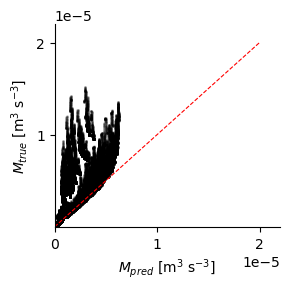

In [18]:
xs, ys = np.linspace(0., 2e-5, 1000), np.linspace(0., 2e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(M, Ms, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=0.8)
ax.set_yticks([1e-5, 2e-5])
ax.set_xticks([0, 1e-5, 2e-5])
ax.set_xlim(0, 2.2e-5)
ax.set_ylim(0, 2.2e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

# plt.savefig("inst_M_true_pred_inst_predictor.png", dpi=600)

In [19]:
np.sqrt(np.mean(((M-Ms)**2)))

np.float64(2.5808082027069238e-06)

(array([  1335.,  34906., 170436., 203701., 207571., 182699., 173092.,
        171342.,  95106.,  10092.]),
 array([-5.97018719, -5.65519191, -5.34019664, -5.02520137, -4.7102061 ,
        -4.39521082, -4.08021555, -3.76522028, -3.45022501, -3.13522973,
        -2.82023446]),
 <BarContainer object of 10 artists>)

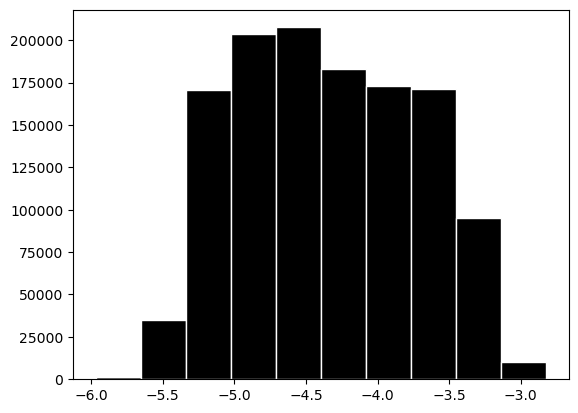

In [59]:
plt.hist(np.log10(NN_bl), color="black", ec="white")

(array([ 46559., 160491., 299762., 338665., 192013., 115986.,  61269.,
         22795.,   9885.,   2855.]),
 array([ 3.74165739,  5.34233341,  6.94300944,  8.54368547, 10.1443615 ,
        11.74503752, 13.34571355, 14.94638958, 16.5470656 , 18.14774163,
        19.74841766]),
 <BarContainer object of 10 artists>)

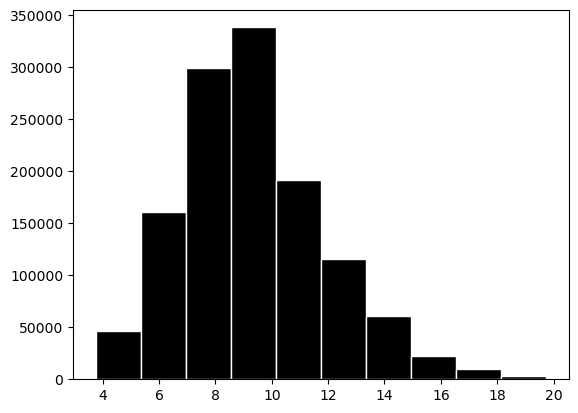

In [60]:
plt.hist(np.sqrt(bls_im1), color="black", ec="white")

(array([ 30085.,  82007.,  28165.,  96078., 108371., 156432., 209084.,
        297807., 225574.,  16677.]),
 array([-2.28229657, -2.05869674, -1.8350969 , -1.61149707, -1.38789723,
        -1.1642974 , -0.94069756, -0.71709773, -0.49349789, -0.26989806,
        -0.04629822]),
 <BarContainer object of 10 artists>)

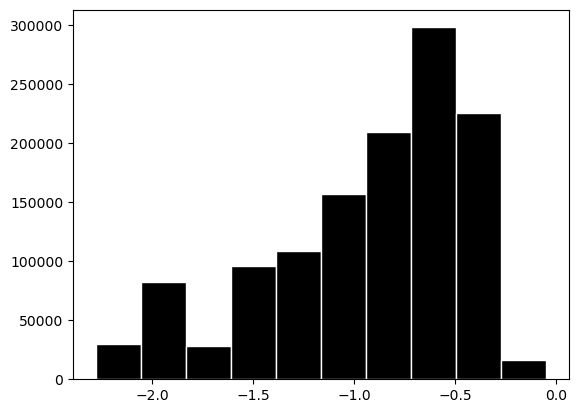

In [61]:
plt.hist(np.log10(surface_magnitudes), color="black", ec="white")

(array([2.00000e+00, 5.00000e+00, 2.50000e+01, 7.40000e+01, 4.87000e+02,
        2.35620e+04, 1.50777e+05, 2.96441e+05, 6.27123e+05, 2.97944e+05]),
 array([-5.53261129, -4.98149942, -4.43038755, -3.87927567, -3.3281638 ,
        -2.77705193, -2.22594006, -1.67482819, -1.12371632, -0.57260444,
        -0.02149257]),
 <BarContainer object of 10 artists>)

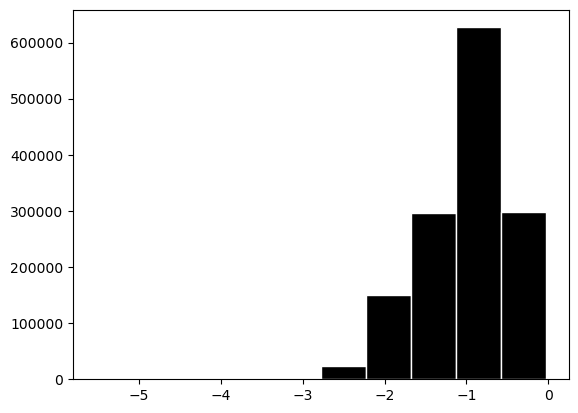

In [33]:
plt.hist(np.log10(surface_ekin_input), color="black", ec="white")

(array([2.50000e+01, 3.49000e+02, 1.89700e+03, 5.80200e+03, 2.05180e+04,
        1.39875e+05, 4.34885e+05, 2.78917e+05, 3.86605e+05, 1.27567e+05]),
 array([-10.05546722,  -9.29047874,  -8.52549027,  -7.76050179,
         -6.99551332,  -6.23052485,  -5.46553637,  -4.7005479 ,
         -3.93555943,  -3.17057095,  -2.40558248]),
 <BarContainer object of 10 artists>)

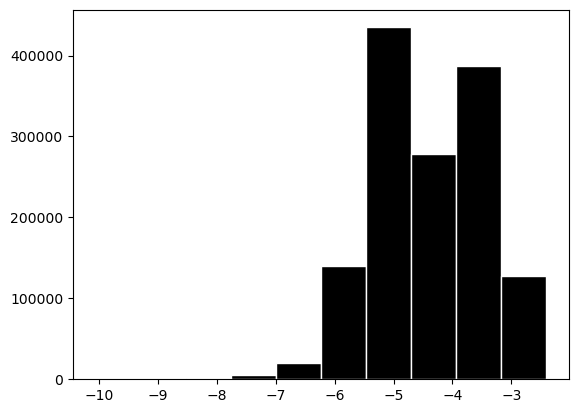

In [34]:
plt.hist(np.log10(SS_bl), color="black", ec="white")

(array([  1896.,   5806.,  60743., 238659., 349855., 385429., 238636.,
         83749.,  27604.,   4063.]),
 array([0.14990901, 0.26245902, 0.37500903, 0.48755903, 0.60010904,
        0.71265905, 0.82520905, 0.93775906, 1.05030907, 1.16285907,
        1.27540908]),
 <BarContainer object of 10 artists>)

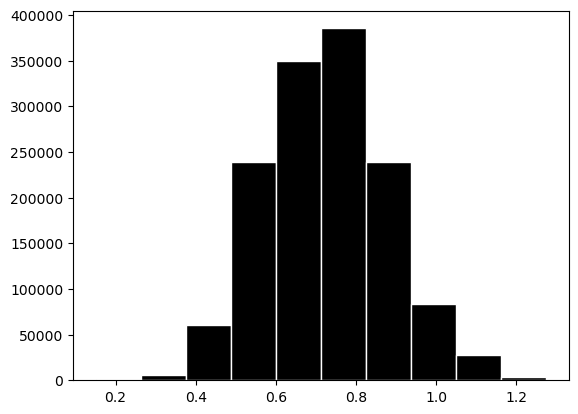

In [35]:
plt.hist(np.sqrt(surface_angles), color="black", ec="white")

In [36]:
# transformations
sqrt_bls = np.sqrt(bls)
sqrt_bls_im1 = np.sqrt(bls_im1)
log_NN_bl = np.log10(NN_bl)
log_SS_bl = np.log10(SS_bl)
sqrt_surface_angles = np.sqrt(surface_angles)
log_surface_ekin_input = np.log10(surface_ekin_input)
log_surface_magnitudes = np.log10(surface_magnitudes)

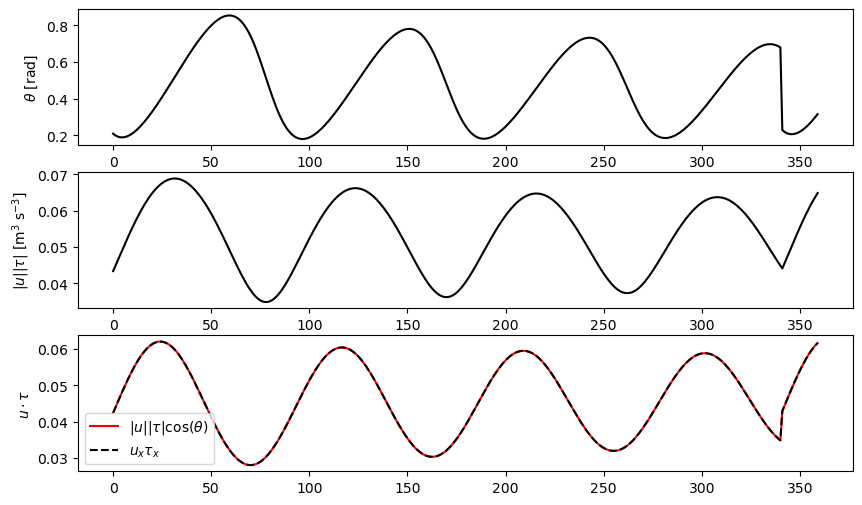

In [69]:
fig, ax = plt.subplots(3,1,figsize=(10,6))

ax[0].set_ylabel(r"$\theta$ [rad]")
ax[0].plot(surface_angles[0:360], color="black")
ax[1].set_ylabel(r"$|u||\tau|$ [m$^3$ s$^{-3}$]")
ax[1].plot(surface_magnitudes[0:360], color="black")
ax[2].set_ylabel(r"$u \cdot \tau$")
ax[2].plot(surface_ekin_input[0:360], color="red", label=r"$|u||\tau|\cos(\theta)$")
ax[2].plot(us[0:360]*taus[0:360], color="black", linestyle="dashed", label=r"$u_x\tau_x$")
ax[2].legend()

In [22]:
torch_dataset_name = f"{dataset_name}_dataset_M_target_dropped_first_inertial_T_NN_SS_bl_avg"
# dataset = torch.tensor(np.array([
#     coriolis_freqs, u_stars, sqrt_bls, Bs, log_surface_magnitudes, sqrt_surface_angles, log_surface_ekin_input, sqrt_bls_im1,
#     us_bl, vs_bl, log_SS_bl, log_NN_bl, 
#     Ms
# ]))
dataset = torch.tensor(np.array([
    fs, u_stars, bls, Bs, surface_magnitudes, surface_angles, surface_ekin_input, bls_im1,
    us_bl, vs_bl, SS_bl, NN_bl, 
    Ms
]))
torch.save(dataset, os.path.join(data_directory, f"{torch_dataset_name}.pt"))

In [88]:
np.save(f"{torch_dataset_name}_timesteps.npy", np.asarray(n_timesteps))

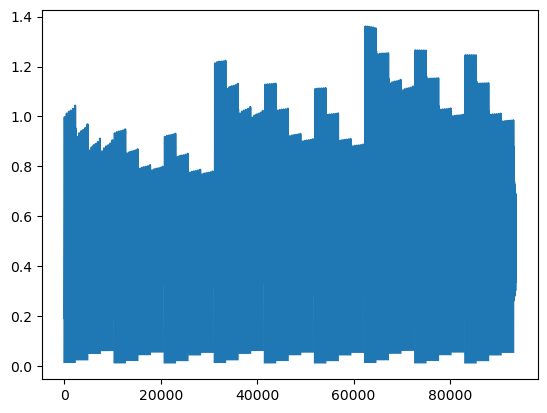

In [52]:
plt.plot(dataset[5,:])